# Getting reach average shear stresses 

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.stats import linregress
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score

# import dicharge data and make date the index
discharge = pd.read_csv('discharge/la_jara_reconstructed_discharge_corrected.csv', index_col='datetime', parse_dates=True)
# rename discharge column
discharge.rename(columns={'discharge_m3s': 'discharge'}, inplace=True)

## Average Shear Stress 

In [3]:
# import shear stress data and make date the index
shear_stress_2022 = pd.read_csv('../shear_stress_record/total_shear_stress_2022.csv', index_col='time', parse_dates=True)
shear_stress_2023 = pd.read_csv('../shear_stress_record/total_shear_stress_2023.csv', index_col='time', parse_dates=True)

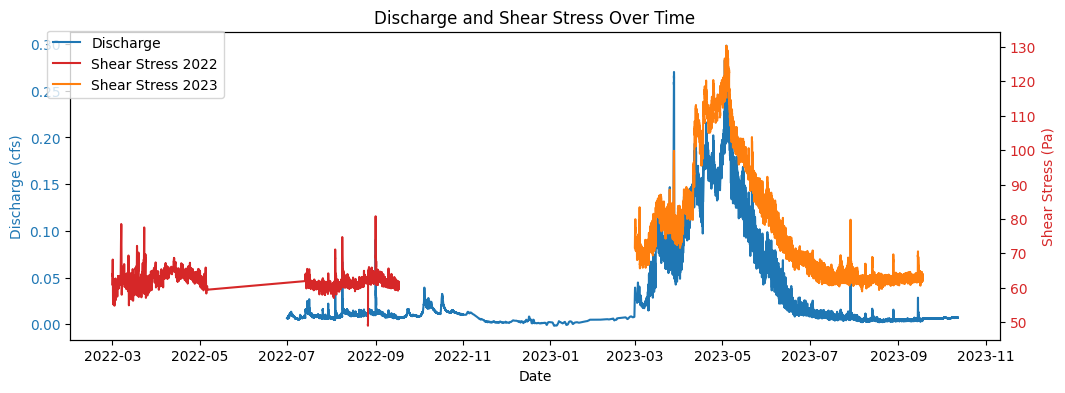

In [4]:
# plot discharge and shear stress over time
fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.set_xlabel('Date')
ax1.set_ylabel('Discharge (cfs)', color='tab:blue') 
ax1.plot(discharge.index, discharge['discharge'], color='tab:blue', label='Discharge')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax2 = ax1.twinx()
ax2.set_ylabel('Shear Stress (Pa)', color='tab:red')
ax2.plot(shear_stress_2022.index, shear_stress_2022['0'], color='tab:red', label='Shear Stress 2022')
ax2.plot(shear_stress_2023.index, shear_stress_2023['0'], color='tab:orange', label='Shear Stress 2023')
ax2.tick_params(axis='y', labelcolor='tab:red') 
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.title('Discharge and Shear Stress Over Time')
plt.show()

### Merge shear stress data onto discharge dataframe

In [5]:
# merge discharge and shear stress data on date
merged_2022 = pd.merge(discharge, shear_stress_2022, left_index=True, right_index=True, how='inner')
merged_2023 = pd.merge(discharge, shear_stress_2023, left_index=True, right_index=True, how='inner')

### Full Range Scatter plots

Linear

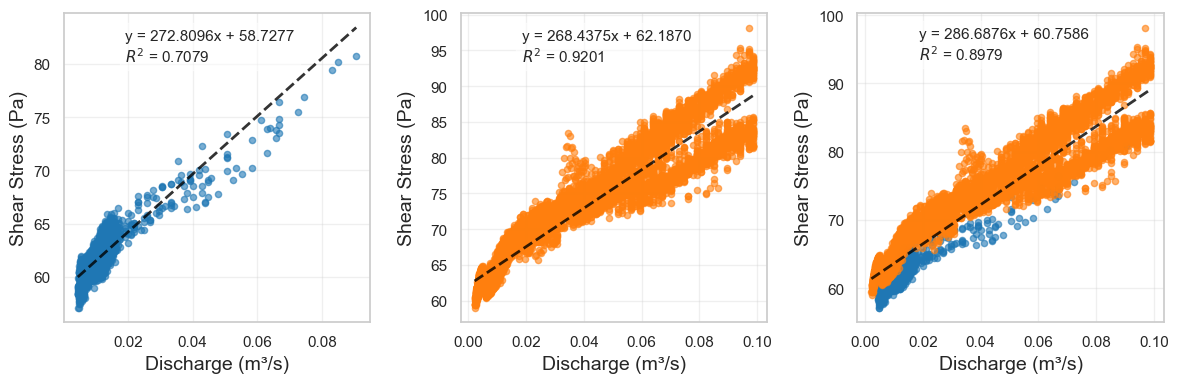

In [34]:
import seaborn as sns
sns.set(style='whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# clean dataframes without NaN values and filter discharge <= 0.1
# use the merged 2022/2023 dataframe format, where the shear-stress column is '0'
df_clean_2022 = merged_2022[['discharge', '0']].dropna()
df_clean_2022 = df_clean_2022[df_clean_2022['discharge'] <= 0.1]
df_clean_2022 = df_clean_2022[df_clean_2022['0'] > 55]
df_clean_2023 = merged_2023[['discharge', '0']].dropna()
df_clean_2023 = df_clean_2023[df_clean_2023['discharge'] <= 0.1]

# discharge vs 2022 shear stress
axes[0].scatter(df_clean_2022['discharge'], df_clean_2022['0'], alpha=0.6, s=20, color='#1f77b4')
slope_2022, intercept_2022, r_value_2022, p_value_2022, std_err_2022 = linregress(df_clean_2022['discharge'], df_clean_2022['0'])
x_line_2022 = np.array([df_clean_2022['discharge'].min(), df_clean_2022['discharge'].max()])
y_line_2022 = slope_2022 * x_line_2022 + intercept_2022
axes[0].plot(x_line_2022, y_line_2022, color='black', linestyle='--', alpha=0.8, linewidth=2)
axes[0].text(0.2, 0.95, f'y = {slope_2022:.4f}x + {intercept_2022:.4f}\n$R^2$ = {r_value_2022**2:.4f}', 
            transform=axes[0].transAxes, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.5), fontsize=11)
axes[0].set_xlabel('Discharge (m³/s)', fontsize=14)
axes[0].set_ylabel('Shear Stress (Pa)', fontsize=14)
#axes[0].set_title('Discharge vs 2022 Shear Stress')
axes[0].grid(True, alpha=0.3)

# discharge vs 2023 shear stress
axes[1].scatter(df_clean_2023['discharge'], df_clean_2023['0'], alpha=0.6, s=20, color='#ff7f0e')
slope_2023, intercept_2023, r_value_2023, p_value_2023, std_err_2023 = linregress(df_clean_2023['discharge'], df_clean_2023['0'])
x_line_2023 = np.array([df_clean_2023['discharge'].min(), df_clean_2023['discharge'].max()])
y_line_2023 = slope_2023 * x_line_2023 + intercept_2023
axes[1].plot(x_line_2023, y_line_2023, color='black', linestyle='--', alpha=0.8, linewidth=2)
axes[1].text(0.2, 0.95, f'y = {slope_2023:.4f}x + {intercept_2023:.4f}\n$R^2$ = {r_value_2023**2:.4f}', 
            transform=axes[1].transAxes, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.5), fontsize=11)
axes[1].set_xlabel('Discharge (m³/s)', fontsize=14)
axes[1].set_ylabel('Shear Stress (Pa)', fontsize=14)
#axes[1].set_title('Discharge vs 2023 Shear Stress')
axes[1].grid(True, alpha=0.3)

# both years with single fit line
axes[2].scatter(df_clean_2022['discharge'], df_clean_2022['0'], alpha=0.6, s=20, label='2022', color='#1f77b4')
axes[2].scatter(df_clean_2023['discharge'], df_clean_2023['0'], alpha=0.6, s=20, color='#ff7f0e', label='2023')
# combine both datasets for single linear fit
combined_data = pd.concat([df_clean_2022.rename(columns={'0': 'shear_stress'}),
                            df_clean_2023.rename(columns={'0': 'shear_stress'})])
slope_combined, intercept_combined, r_value_combined, p_value_combined, std_err_combined = linregress(combined_data['discharge'], combined_data['shear_stress'])
x_line_combined = np.array([combined_data['discharge'].min(), combined_data['discharge'].max()])
y_line_combined = slope_combined * x_line_combined + intercept_combined
axes[2].plot(x_line_combined, y_line_combined, color='black', linestyle='--', alpha=0.8, linewidth=2, label=f'Combined fit: $R^2$ = {r_value_combined**2:.4f}')

axes[2].set_xlabel('Discharge (m³/s)', fontsize=14)
axes[2].set_ylabel('Shear Stress (Pa)', fontsize=14)
#axes[2].set_title('Discharge vs Shear Stress (2022 & 2023)')
axes[2].text(0.2, 0.85, f'y = {slope_combined:.4f}x + {intercept_combined:.4f}\n$R^2$ = {r_value_combined**2:.4f}', 
            transform=axes[2].transAxes, bbox=dict(facecolor='white', alpha=0.5), fontsize=11)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('discharge_vs_shear_stress_ratingcurves.png', dpi=300)
plt.show()

Power Law

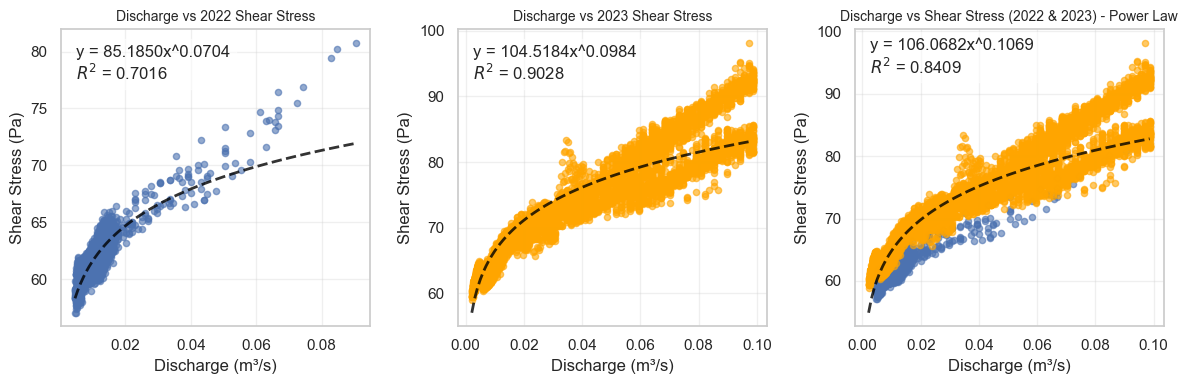

In [14]:
# define power law function
def power_law(x, a, b):
    return a * np.power(x, b)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# clean dataframes without NaN values and filter discharge <= 0.1
# use the merged 2022/2023 dataframe format, where the shear-stress column is '0'
df_clean_2022 = merged_2022[['discharge', '0']].dropna()
df_clean_2022 = df_clean_2022[df_clean_2022['discharge'] <= 0.1]
df_clean_2022 = df_clean_2022[df_clean_2022['0'] > 55]
df_clean_2023 = merged_2023[['discharge', '0']].dropna()
df_clean_2023 = df_clean_2023[df_clean_2023['discharge'] <= 0.1]

# discharge vs 2022 shear stress
axes[0].scatter(df_clean_2022['discharge'], df_clean_2022['0'], alpha=0.6, s=20)
try:
    popt_2022, pcov_2022 = curve_fit(power_law, df_clean_2022['discharge'], df_clean_2022['0'], p0=[1, 2], maxfev=10000)
    x_line_2022_pw = np.linspace(df_clean_2022['discharge'].min(), df_clean_2022['discharge'].max(), 100)
    y_line_2022_pw = power_law(x_line_2022_pw, *popt_2022)
    y_pred_2022_pw = power_law(df_clean_2022['discharge'], *popt_2022)
    r2_2022_pw = r2_score(df_clean_2022['0'], y_pred_2022_pw)
    axes[0].plot(x_line_2022_pw, y_line_2022_pw, color='black', alpha=0.8, linewidth=2, linestyle='--')
    axes[0].text(0.05, 0.95, f'y = {popt_2022[0]:.4f}x^{popt_2022[1]:.4f}\n$R^2$ = {r2_2022_pw:.4f}', 
                transform=axes[0].transAxes, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.5))
except:
    axes[0].text(0.5, 0.5, 'Fit failed', ha='center', va='center', transform=axes[0].transAxes)
axes[0].set_xlabel('Discharge (m³/s)')
axes[0].set_ylabel('Shear Stress (Pa)')
axes[0].set_title('Discharge vs 2022 Shear Stress', fontsize=10)
axes[0].grid(True, alpha=0.3)

# discharge vs 2023 shear stress
axes[1].scatter(df_clean_2023['discharge'], df_clean_2023['0'], alpha=0.6, s=20, color='orange')
try:
    popt_2023, pcov_2023 = curve_fit(power_law, df_clean_2023['discharge'], df_clean_2023['0'], p0=[1, 2], maxfev=10000)
    x_line_2023_pw = np.linspace(df_clean_2023['discharge'].min(), df_clean_2023['discharge'].max(), 100)
    y_line_2023_pw = power_law(x_line_2023_pw, *popt_2023)
    y_pred_2023_pw = power_law(df_clean_2023['discharge'], *popt_2023)
    r2_2023_pw = r2_score(df_clean_2023['0'], y_pred_2023_pw)
    axes[1].plot(x_line_2023_pw, y_line_2023_pw, color='black', alpha=0.8, linewidth=2, linestyle='--')
    axes[1].text(0.05, 0.95, f'y = {popt_2023[0]:.4f}x^{popt_2023[1]:.4f}\n$R^2$ = {r2_2023_pw:.4f}', 
                transform=axes[1].transAxes, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.5))
except:
    axes[1].text(0.5, 0.5, 'Fit failed', ha='center', va='center', transform=axes[1].transAxes)
axes[1].set_xlabel('Discharge (m³/s)')
axes[1].set_ylabel('Shear Stress (Pa)')
axes[1].set_title('Discharge vs 2023 Shear Stress', fontsize=10)
axes[1].grid(True, alpha=0.3)

# both years with power law fit
axes[2].scatter(df_clean_2022['discharge'], df_clean_2022['0'], alpha=0.6, s=20, label='2022')
axes[2].scatter(df_clean_2023['discharge'], df_clean_2023['0'], alpha=0.6, s=20, color='orange', label='2023')
try:
    popt_combined, pcov_combined = curve_fit(power_law, combined_data['discharge'], combined_data['shear_stress'], p0=[1, 2], maxfev=10000)
    x_line_combined_pw = np.linspace(combined_data['discharge'].min(), combined_data['discharge'].max(), 100)
    y_line_combined_pw = power_law(x_line_combined_pw, *popt_combined)
    y_pred_combined_pw = power_law(combined_data['discharge'], *popt_combined)
    r2_combined_pw = r2_score(combined_data['shear_stress'], y_pred_combined_pw)
    axes[2].plot(x_line_combined_pw, y_line_combined_pw, color='black', linestyle='--', alpha=0.8, linewidth=2, label=f'Combined fit: $R^2$ = {r2_combined_pw:.4f}')
    axes[2].text(0.05, 0.85, f'y = {popt_combined[0]:.4f}x^{popt_combined[1]:.4f}\n$R^2$ = {r2_combined_pw:.4f}', 
                transform=axes[2].transAxes, bbox=dict(facecolor='white', alpha=0.5))
except:
    axes[2].text(0.5, 0.5, 'Fit failed', ha='center', va='center', transform=axes[2].transAxes)
axes[2].set_xlabel('Discharge (m³/s)')
axes[2].set_ylabel('Shear Stress (Pa)')
axes[2].set_title('Discharge vs Shear Stress (2022 & 2023) - Power Law', fontsize=10)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Calculate shear stress using equations

In [15]:
# calculate shear stress using year-specific linear fits
# 2022 uses slope_2022/intercept_2022, 2023 uses slope_2023/intercept_2023
discharge['tau_linear_yearly'] = np.nan

q = discharge['discharge']
years = discharge.index.year

# linear fit can be applied to any non-NaN discharge (optionally keep q > 0 if you want)
valid_q = q.notna() & (q > 0)
# apply 2022 fit through end of March 2023 to avoid Jan 01 jump
split_date = pd.Timestamp("2023-04-01")
mask_2022_fit = (discharge.index < split_date) & valid_q
mask_2023_fit = (discharge.index >= split_date) & valid_q

# tau = mQ + b
discharge.loc[mask_2022_fit, "tau_linear_yearly"] = (
    slope_2022 * q.loc[mask_2022_fit] + intercept_2022
)
discharge.loc[mask_2023_fit, "tau_linear_yearly"] = (
    slope_2023 * q.loc[mask_2023_fit] + intercept_2023
)
# optional: prevent negative shear stress values
discharge['tau_linear_yearly'] = discharge['tau_linear_yearly'].clip(lower=0)
# quick check
print(discharge[['discharge', 'tau_linear_yearly']])

                     discharge  tau_linear_yearly
datetime                                         
2022-07-01 00:00:00   0.006721          60.561201
2022-07-01 00:15:00   0.006856          60.598135
2022-07-01 00:30:00   0.006643          60.539969
2022-07-01 00:45:00   0.006794          60.581092
2022-07-01 01:00:00   0.006914          60.613800
...                        ...                ...
2023-10-12 11:45:00   0.007049          64.079107
2023-10-12 12:00:00   0.006965          64.056636
2023-10-12 12:15:00   0.007226          64.126763
2023-10-12 12:30:00   0.007103          64.093774
2023-10-12 12:45:00   0.007165          64.110374

[38976 rows x 2 columns]


In [16]:
discharge['tau_linear_total'] = np.nan

# tau = mQ + b
discharge["tau_linear_total"] = (
    slope_combined * discharge['discharge'] + intercept_combined
)
# optional: prevent negative shear stress values
discharge['tau_linear_total'] = discharge['tau_linear_total'].clip(lower=0)
# quick check
print(discharge)

                     discharge  tau_linear_yearly  tau_linear_total
datetime                                                           
2022-07-01 00:00:00   0.006721          60.561201         62.685375
2022-07-01 00:15:00   0.006856          60.598135         62.724188
2022-07-01 00:30:00   0.006643          60.539969         62.663064
2022-07-01 00:45:00   0.006794          60.581092         62.706278
2022-07-01 01:00:00   0.006914          60.613800         62.740650
...                        ...                ...               ...
2023-10-12 11:45:00   0.007049          64.079107         62.779369
2023-10-12 12:00:00   0.006965          64.056636         62.755371
2023-10-12 12:15:00   0.007226          64.126763         62.830266
2023-10-12 12:30:00   0.007103          64.093774         62.795034
2023-10-12 12:45:00   0.007165          64.110374         62.812763

[38976 rows x 3 columns]


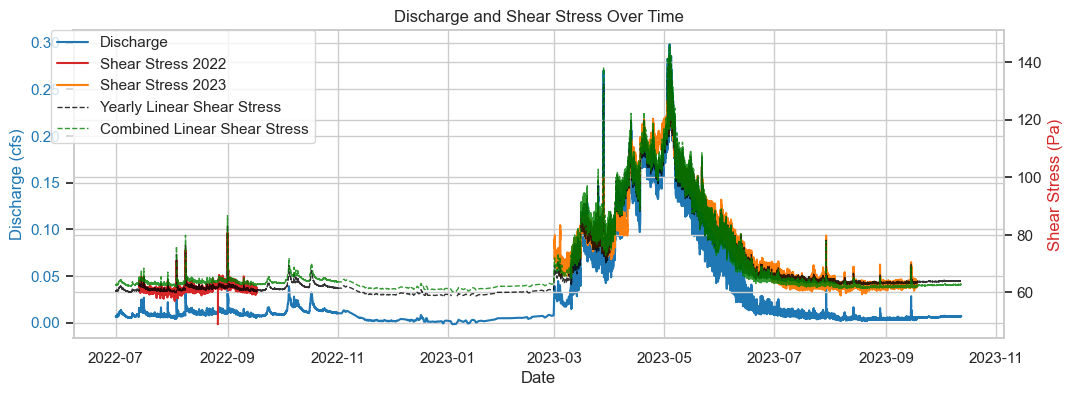

In [17]:
# plot discharge and shear stress over time
fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.set_xlabel('Date')
ax1.set_ylabel('Discharge (cfs)', color='tab:blue') 
ax1.plot(discharge.index, discharge['discharge'], color='tab:blue', label='Discharge')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.set_ylabel('Shear Stress (Pa)', color='tab:red')
# align the merged series back to the full discharge index for plotting
tau_2022 = merged_2022['0'].reindex(discharge.index)
tau_2023 = merged_2023['0'].reindex(discharge.index)
ax2.plot(discharge.index, tau_2022, color='tab:red', label='Shear Stress 2022')
ax2.plot(discharge.index, tau_2023, color='tab:orange', label='Shear Stress 2023')

for column_name, label, color in [
    ('tau_linear_yearly', 'Yearly Linear Shear Stress', 'black'),
    ('tau_linear_total', 'Combined Linear Shear Stress', 'green'),
]:
    if column_name in discharge.columns:
        ax2.plot(
            discharge.index,
            discharge[column_name],
            color=color,
            label=label,
            alpha=0.8,
            linestyle='--',
            linewidth=1,
        )

ax2.tick_params(axis='y') 
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.title('Discharge and Shear Stress Over Time')
plt.show()

### Summer and Fall Scatter plots

Linear

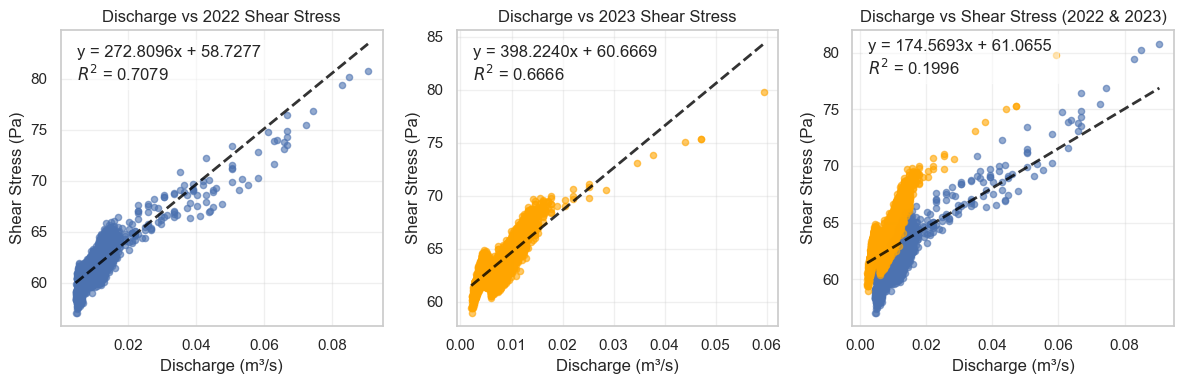

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# clean dataframes without NaN values and filter discharge <= 0.1
# exclude spring snowmelt months (March-May)
# use the merged 2022/2023 dataframe format, where the shear-stress column is '0'
df_clean_2022 = merged_2022[['discharge', '0']].dropna()
df_clean_2022 = df_clean_2022[df_clean_2022['discharge'] <= 0.1]
df_clean_2022 = df_clean_2022[df_clean_2022['0'] > 55]
df_clean_2022 = df_clean_2022[~df_clean_2022.index.month.isin([3, 4, 5, 6])]

df_clean_2023 = merged_2023[['discharge', '0']].dropna()
df_clean_2023 = df_clean_2023[df_clean_2023['discharge'] <= 0.1]
df_clean_2023 = df_clean_2023[~df_clean_2023.index.month.isin([3, 4, 5, 6])]

# discharge vs 2022 shear stress
axes[0].scatter(df_clean_2022['discharge'], df_clean_2022['0'], alpha=0.6, s=20)
slope_2022, intercept_2022, r_value_2022, p_value_2022, std_err_2022 = linregress(df_clean_2022['discharge'], df_clean_2022['0'])
x_line_2022 = np.array([df_clean_2022['discharge'].min(), df_clean_2022['discharge'].max()])
y_line_2022 = slope_2022 * x_line_2022 + intercept_2022
axes[0].plot(x_line_2022, y_line_2022, color='black', linestyle='--', alpha=0.8, linewidth=2)
axes[0].text(0.05, 0.95, f'y = {slope_2022:.4f}x + {intercept_2022:.4f}\n$R^2$ = {r_value_2022**2:.4f}', 
             transform=axes[0].transAxes, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.5))
axes[0].set_xlabel('Discharge (m³/s)')
axes[0].set_ylabel('Shear Stress (Pa)')
axes[0].set_title('Discharge vs 2022 Shear Stress')
axes[0].grid(True, alpha=0.3)

# discharge vs 2023 shear stress
axes[1].scatter(df_clean_2023['discharge'], df_clean_2023['0'], alpha=0.6, s=20, color='orange')
slope_2023, intercept_2023, r_value_2023, p_value_2023, std_err_2023 = linregress(df_clean_2023['discharge'], df_clean_2023['0'])
x_line_2023 = np.array([df_clean_2023['discharge'].min(), df_clean_2023['discharge'].max()])
y_line_2023 = slope_2023 * x_line_2023 + intercept_2023
axes[1].plot(x_line_2023, y_line_2023, color='black', linestyle='--', alpha=0.8, linewidth=2)
axes[1].text(0.05, 0.95, f'y = {slope_2023:.4f}x + {intercept_2023:.4f}\n$R^2$ = {r_value_2023**2:.4f}', 
             transform=axes[1].transAxes, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.5))
axes[1].set_xlabel('Discharge (m³/s)')
axes[1].set_ylabel('Shear Stress (Pa)')
axes[1].set_title('Discharge vs 2023 Shear Stress')
axes[1].grid(True, alpha=0.3)

# both years with single fit line
axes[2].scatter(df_clean_2022['discharge'], df_clean_2022['0'], alpha=0.6, s=20, label='2022')
axes[2].scatter(df_clean_2023['discharge'], df_clean_2023['0'], alpha=0.6, s=20, color='orange', label='2023')
# combine both datasets for single linear fit
combined_data = pd.concat([
    df_clean_2022[['discharge', '0']].rename(columns={'0': 'shear_stress'}),
    df_clean_2023[['discharge', '0']].rename(columns={'0': 'shear_stress'})
])
slope_combined, intercept_combined, r_value_combined, p_value_combined, std_err_combined = linregress(combined_data['discharge'], combined_data['shear_stress'])
x_line_combined = np.array([combined_data['discharge'].min(), combined_data['discharge'].max()])
y_line_combined = slope_combined * x_line_combined + intercept_combined
axes[2].plot(x_line_combined, y_line_combined, color='black', linestyle='--', alpha=0.8, linewidth=2, label=f'Combined fit: $R^2$ = {r_value_combined**2:.4f}')

axes[2].set_xlabel('Discharge (m³/s)')
axes[2].set_ylabel('Shear Stress (Pa)')
axes[2].set_title('Discharge vs Shear Stress (2022 & 2023)')
axes[2].text(0.05, 0.85, f'y = {slope_combined:.4f}x + {intercept_combined:.4f}\n$R^2$ = {r_value_combined**2:.4f}', 
             transform=axes[2].transAxes, bbox=dict(facecolor='white', alpha=0.5))
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Power Law

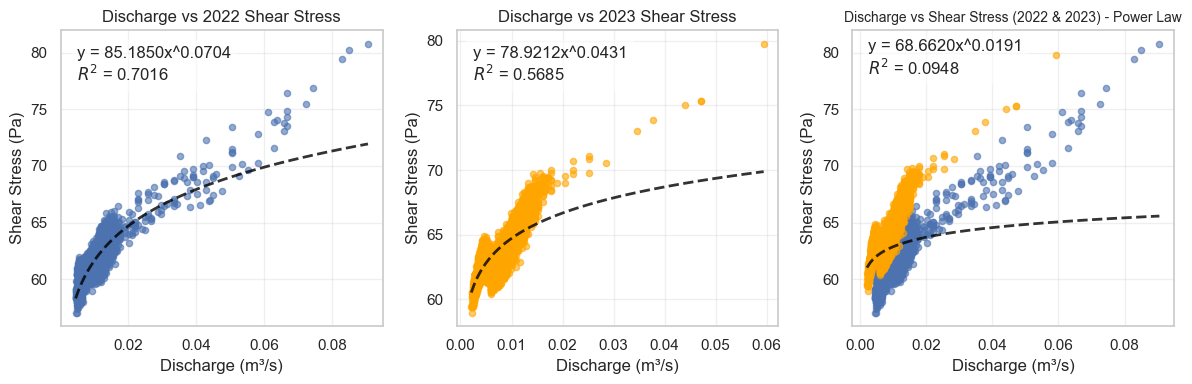

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# clean dataframes without NaN values and filter discharge <= 0.1
# use the merged 2022/2023 dataframe format, where the shear-stress column is '0'
df_clean_2022 = merged_2022[['discharge', '0']].dropna()
df_clean_2022 = df_clean_2022[df_clean_2022['discharge'] <= 0.1]
df_clean_2022 = df_clean_2022[df_clean_2022['0'] > 55]
df_clean_2022 = df_clean_2022[~df_clean_2022.index.month.isin([3, 4, 5, 6])]

df_clean_2023 = merged_2023[['discharge', '0']].dropna()
df_clean_2023 = df_clean_2023[df_clean_2023['discharge'] <= 0.1]
df_clean_2023 = df_clean_2023[~df_clean_2023.index.month.isin([3, 4, 5, 6])]

# discharge vs 2022 shear stress
axes[0].scatter(df_clean_2022['discharge'], df_clean_2022['0'], alpha=0.6, s=20)
try:
    popt_2022, pcov_2022 = curve_fit(power_law, df_clean_2022['discharge'], df_clean_2022['0'], p0=[1, 2], maxfev=10000)
    x_line_2022_pw = np.linspace(df_clean_2022['discharge'].min(), df_clean_2022['discharge'].max(), 100)
    y_line_2022_pw = power_law(x_line_2022_pw, *popt_2022)
    y_pred_2022_pw = power_law(df_clean_2022['discharge'], *popt_2022)
    r2_2022_pw = r2_score(df_clean_2022['0'], y_pred_2022_pw)
    axes[0].plot(x_line_2022_pw, y_line_2022_pw, color='black', alpha=0.8, linewidth=2, linestyle='--')
    axes[0].text(0.05, 0.95, f'y = {popt_2022[0]:.4f}x^{popt_2022[1]:.4f}\n$R^2$ = {r2_2022_pw:.4f}', 
                transform=axes[0].transAxes, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.5))
except:
    axes[0].text(0.5, 0.5, 'Fit failed', ha='center', va='center', transform=axes[0].transAxes)
axes[0].set_xlabel('Discharge (m³/s)')
axes[0].set_ylabel('Shear Stress (Pa)')
axes[0].set_title('Discharge vs 2022 Shear Stress')
axes[0].grid(True, alpha=0.3)

# discharge vs 2023 shear stress
axes[1].scatter(df_clean_2023['discharge'], df_clean_2023['0'], alpha=0.6, s=20, color='orange')
try:
    popt_2023, pcov_2023 = curve_fit(power_law, df_clean_2023['discharge'], df_clean_2023['0'], p0=[1, 2], maxfev=10000)
    x_line_2023_pw = np.linspace(df_clean_2023['discharge'].min(), df_clean_2023['discharge'].max(), 100)
    y_line_2023_pw = power_law(x_line_2023_pw, *popt_2023)
    y_pred_2023_pw = power_law(df_clean_2023['discharge'], *popt_2023)
    r2_2023_pw = r2_score(df_clean_2023['0'], y_pred_2023_pw)
    axes[1].plot(x_line_2023_pw, y_line_2023_pw, color='black', alpha=0.8, linewidth=2, linestyle='--')
    axes[1].text(0.05, 0.95, f'y = {popt_2023[0]:.4f}x^{popt_2023[1]:.4f}\n$R^2$ = {r2_2023_pw:.4f}', 
                 transform=axes[1].transAxes, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.5))
except:
    axes[1].text(0.5, 0.5, 'Fit failed', ha='center', va='center', transform=axes[1].transAxes)
axes[1].set_xlabel('Discharge (m³/s)')
axes[1].set_ylabel('Shear Stress (Pa)')
axes[1].set_title('Discharge vs 2023 Shear Stress')
axes[1].grid(True, alpha=0.3)

# both years with power law fit
axes[2].scatter(df_clean_2022['discharge'], df_clean_2022['0'], alpha=0.6, s=20, label='2022')
axes[2].scatter(df_clean_2023['discharge'], df_clean_2023['0'], alpha=0.6, s=20, color='orange', label='2023')
try:
    popt_combined, pcov_combined = curve_fit(power_law, combined_data['discharge'], combined_data['shear_stress'], p0=[1, 2], maxfev=10000)
    x_line_combined_pw = np.linspace(combined_data['discharge'].min(), combined_data['discharge'].max(), 100)
    y_line_combined_pw = power_law(x_line_combined_pw, *popt_combined)
    y_pred_combined_pw = power_law(combined_data['discharge'], *popt_combined)
    r2_combined_pw = r2_score(combined_data['shear_stress'], y_pred_combined_pw)
    axes[2].plot(x_line_combined_pw, y_line_combined_pw, color='black', linestyle='--', alpha=0.8, linewidth=2, label=f'Combined fit: $R^2$ = {r2_combined_pw:.4f}')
    axes[2].text(0.05, 0.85, f'y = {popt_combined[0]:.4f}x^{popt_combined[1]:.4f}\n$R^2$ = {r2_combined_pw:.4f}', 
                 transform=axes[2].transAxes, bbox=dict(facecolor='white', alpha=0.5))
except:
    axes[2].text(0.5, 0.5, 'Fit failed', ha='center', va='center', transform=axes[2].transAxes)
axes[2].set_xlabel('Discharge (m³/s)')
axes[2].set_ylabel('Shear Stress (Pa)')
axes[2].set_title('Discharge vs Shear Stress (2022 & 2023) - Power Law', fontsize=10)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
# build one continuous shear stress dataframe:
# combine measured columns into a single measured series
tau_measured = merged_2022['0'].combine_first(merged_2023['0'])
tau_final = tau_measured.combine_first(discharge['tau_linear_yearly'])

# replace 03/01 through 03/03 with rating-curve calculated values
march_mask = (
    (tau_final.index >= pd.Timestamp('2023-03-01')) &
    (tau_final.index < pd.Timestamp('2023-03-04'))
)

tau_final.loc[march_mask] = discharge.loc[march_mask, 'tau_linear_yearly']

# resample to 15 min intervals and fill data gaps
tau_final = tau_final.resample('15min').interpolate()

# treat pre-September lows as missing, then re-interpolate
pre_sep_low = (tau_final.index < pd.Timestamp('2023-09-01')) & (tau_final < 55)
tau_final = tau_final.mask(pre_sep_low)
tau_final = tau_final.interpolate(method='time', limit_area='inside')

# convert to DataFrame
tau_final = tau_final.to_frame(name='shear_stress')

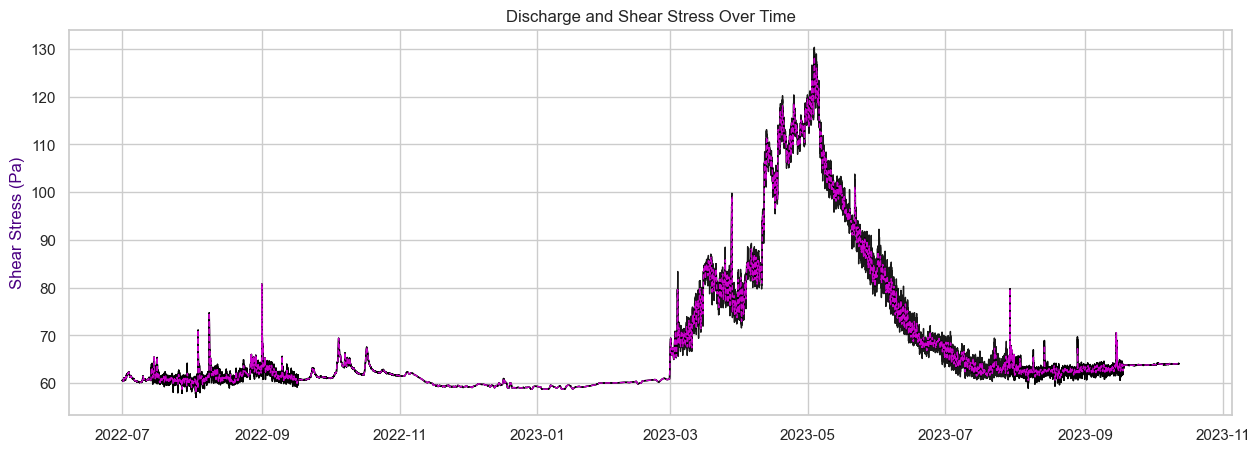

In [ ]:
# copy original data
tau_final['shear_smooth'] = tau_final['shear_stress']
# select March–June period
mask = (tau_final.index >= pd.Timestamp('2023-03-03')) & (tau_final.index <= pd.Timestamp('2023-07-29'))
# apply smoothing only within this window
tau_final.loc[mask, 'shear_smooth'] = (
    tau_final.loc[mask, 'shear_stress']
    .rolling(window=20, center=True)
    .median()
)
threshold = 65   # Pa
# compute smoothing
baseflow_smooth = tau_final['shear_stress'].rolling(
    window=25, center=True
).median()
# apply smoothing only during baseflow
tau_final['shear_smooth_final'] = np.where(
    tau_final['shear_smooth'] < threshold,
    baseflow_smooth,
    tau_final['shear_smooth']
)
mask = (
    ((tau_final.index >= '2022-09-15') & (tau_final.index <= '2022-11-20')) |
    ((tau_final.index >= '2023-08-01') & (tau_final.index <= '2023-09-10'))
)
tau_final.loc[mask, 'shear_smooth_final'] = (
    tau_final.loc[mask, 'shear_smooth_final']
    .rolling(window=7, center=True)
    .median()
)

# plot discharge and shear stress over time
plt.figure(figsize=(10, 5))
plt.plot(tau_final.index, tau_final, color='black', label='Final Shear Stress', alpha=0.9, linestyle='-', linewidth=1)
plt.plot(tau_final.index, tau_final['shear_smooth_final'], color='magenta', label='Smoothed Shear Stress', alpha=0.8, linestyle='--', linewidth=1)
plt.tick_params(axis='y')   
plt.ylabel('Shear Stress (Pa)', color='indigo')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.title('Discharge and Shear Stress Over Time')
plt.show()

In [23]:
# resample to 15 min intervals and fill data gaps 
tau_final = tau_final.resample('15min').interpolate()
# final dataframe 
shear_stress = pd.DataFrame({
    'datetime': tau_final.index,
    'shear_stress': tau_final['shear_smooth_final']
}).reset_index(drop=True)

# export to csv
shear_stress.to_csv('average_shear_stress_lajara_full.csv', index=False)